# Brain Bleed Algorithm Evaluation

**Structure**
- Part 1: Data Exploration: population, demographics, treatment duration, ICH prevalence.
- Part 2: Algorithm Performance Evaluation: accuracy metrics, agreement, speed, operational impact

**Code organization.** The analysis logic is kept modular: four independent, single-purpose
files shipped alongside this notebook, each importable and reusable on its own. This
notebook is a consumer of that code: it imports the modules below and calls into
them cell by cell.

**What each module does:**
- `data_loader.py`: loads the raw data file and builds the cleaned, analysis-ready dataframe.
- `exploration.py`: computes the Part 1 data-exploration summaries.
- `performance.py`: computes the Part 2 algorithm-performance metrics and functions.
- `viz.py`: renders every chart used across both parts of the notebook.

**A note on modularity.** "Modular" here refers to separating the analysis by pipeline stage into independent, single-purpose files with no duplicated logic between them, and not to generalizing the code to arbitrary datasets. Column names are used directly as fixed values throughout, on the assumption that this schema is the given, unchanging structure of the source table for this analysis, not a variable to be configured. Reusing these modules on a dataset with a different column layout would require editing the functions directly.


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from data_loader import load_and_prepare, AGE_LABELS
import exploration as ex
import performance as perf
import viz

In data_loader.py, I've created a loading function and two cleaning functions. So now I will use them:

In [2]:
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)
DATA_PATH = "ICH_data.csv"
df, quality = load_and_prepare(DATA_PATH)
print(f"Loaded {len(df):,} scans, {df.shape[1]} columns.")
df.head()

Loaded 20,000 scans, 26 columns.


,site,accession,patient_class,gender,age,scan_timestamp,radiologist_answer,radiologist_sign_time,algo1_answer,algos_start_run,...,start_delay_s,algo1_runtime_s,algo2_runtime_s,algo3_runtime_s,is_ed,rad_positive,age_group,scan_hour,scan_dow,scan_month
0,healthy_vibes,30990315,ED,male,32,2021-02-10 00:03:00,P,2021-02-10 00:14:00,P,2021-02-10 00:03:00,...,0.0,60.0,120.0,300.0,True,True,30-40,0,Wednesday,2021-02
1,healthy_vibes,90798806,ED,male,42,2021-09-30 14:38:00,P,2021-09-30 14:49:00,P,2021-09-30 14:39:00,...,60.0,0.0,120.0,600.0,True,True,40-50,14,Thursday,2021-09
2,healthy_vibes,55615848,ED,male,43,2021-11-07 18:17:00,P,2021-11-07 18:25:00,P,2021-11-07 18:17:00,...,0.0,60.0,120.0,720.0,True,True,40-50,18,Sunday,2021-11
3,healthy_vibes,91835094,ED,male,69,2021-04-25 13:17:00,P,2021-04-25 13:27:00,N,2021-04-25 13:17:00,...,0.0,60.0,240.0,660.0,True,True,60-70,13,Sunday,2021-04
4,healthy_vibes,72427516,ED,male,38,2021-01-17 21:47:00,P,2021-01-17 21:56:00,N,2021-01-17 21:47:00,...,0.0,60.0,180.0,720.0,True,True,30-40,21,Sunday,2021-01


# Part 1: Data Exploration


## 1.1 Data Quality Checks

Before trusting any metric, we will check the raw data for issues: missing values, duplicated
accessions, and timestamp inconsistencies.

In [3]:
for key, val in quality.items():
    if hasattr(val, '__len__'):
        if key in ("missing_values", "empty_string_values"):
            n_cols = len(val)          # how many columns are affected
            n_total = int(val.sum())   # total missing/empty cells across those columns
            print(f"{key:32s}: {n_cols} column(s) affected, {n_total} total cells")
        else:
            n = len(val)                # row-based checks (duplicates, negative durations, etc.)
            print(f"{key:32s}: {n} row(s)")
    else:
        print(f"{key:32s}: {val}")

print()
print("Duplicated accessions:")
print(quality['duplicated_accessions'])
print()
print("Rows with negative radiologist scan duration:")
print(quality['negative_duration_rows'][['site','scan_timestamp','radiologist_sign_time']])
print()
print("Rows with negative start delay (algorithms started before scan):")
print(quality['negative_start_delay_rows'][['site', 'scan_timestamp', 'algos_start_run']])
print()
print()
print("Rows with negative algorithm runtime (finish before start):")

neg_runtime_frames = []
for algo in ["algo1", "algo2", "algo3"]:
    rows = quality[f"negative_{algo}_runtime_rows"][["site", "algos_start_run", f"{algo}_finish_run"]].copy()
    rows = rows.rename(columns={f"{algo}_finish_run": "finish_run"})
    rows["algo"] = algo
    rows["gap_seconds"] = (rows["finish_run"] - rows["algos_start_run"]).dt.total_seconds()
    rows = rows[["algo", "site", "algos_start_run", "finish_run", "gap_seconds"]]
    neg_runtime_frames.append(rows)

neg_runtime_all = pd.concat(neg_runtime_frames)
print(neg_runtime_all)
gap = (neg_runtime_all["finish_run"] - neg_runtime_all["algos_start_run"]).dt.total_seconds()
print("Range:", gap.min(), "to", gap.max(), "seconds")
print("Average:", gap.mean(), "seconds")

missing_values                  : 0 column(s) affected, 0 total cells
empty_string_values             : 0 column(s) affected, 0 total cells
duplicated_accessions           : 2 row(s)
negative_duration_rows          : 1 row(s)
negative_start_delay_rows       : 3 row(s)
negative_algo1_runtime_rows     : 17 row(s)
negative_algo2_runtime_rows     : 0 row(s)
negative_algo3_runtime_rows     : 0 row(s)

Duplicated accessions:
      accession           site      scan_timestamp
2594   37729340  healthy_vibes 2021-09-10 05:36:55
4750   37729340  healthy_vibes 2021-08-07 08:42:46

Rows with negative radiologist scan duration:
                site      scan_timestamp   radiologist_sign_time
14464  healthy_vibes 2021-05-15 05:38:52 2021-05-15 05:38:35.768

Rows with negative start delay (algorithms started before scan):
                site      scan_timestamp         algos_start_run
6615   healthy_vibes 2021-07-27 20:32:39 2021-07-27 20:32:38.214
14504  healthy_vibes 2021-08-30 19:02:37 2021-08-30

**Takeaway:** the dataset is essentially clean: 20,000 rows, zero missing values, and only a
handful of rows with a timing inconsistency: 1 duplicated accession, 1 negative treatment duration, and 17 negative algorithm runtimes (from algo1 only). These negative runtimes are between 0.2 seconds and 13 seconds, and are probably
clock/rounding artifacts from the data generator, immaterial at this volume: they're
called out here rather than silently dropped, and are left in for the aggregate analysis below.

## 1.2 Demographics of Sites & Classes

First, let's examine the major statistics of the Int and Timestamp columns:

In [4]:
desc = df.drop(columns="accession").describe().round(1)

split_col = "algo3_finish_run"
split_idx = desc.columns.get_loc(split_col) + 1  

display(desc.iloc[:, :split_idx])

,age,scan_timestamp,radiologist_sign_time,algos_start_run,algo1_finish_run,algo2_finish_run,algo3_finish_run
count,20000.0,20000,20000,20000,20000,20000,20000
mean,48.5,2021-06-18 09:16:03.345849856,2021-06-18 09:26:22.438008320,2021-06-18 09:16:38.777934336,2021-06-18 09:17:23.768539904,2021-06-18 09:19:08.697431040,2021-06-18 09:26:40.146345472
min,5.0,2021-01-02 00:04:02,2021-01-02 00:14:28.638000,2021-01-02 00:05:19.071000,2021-01-02 00:05:53.265000,2021-01-02 00:07:23.076000,2021-01-02 00:17:15.535000
25%,35.0,2021-03-27 20:43:11.500000,2021-03-27 20:51:57.107749888,2021-03-27 20:43:38.599000064,2021-03-27 20:44:36.939000064,2021-03-27 20:46:00.040000,2021-03-27 20:51:48.069499904
50%,49.0,2021-06-18 02:13:13.500000,2021-06-18 02:24:01.587500032,2021-06-18 02:13:55.671000064,2021-06-18 02:14:57.073500160,2021-06-18 02:15:53.548999936,2021-06-18 02:23:14.140499968
75%,63.0,2021-09-09 20:31:40,2021-09-09 20:42:37.986249984,2021-09-09 20:32:07.103249920,2021-09-09 20:33:06.017250048,2021-09-09 20:35:16.030749952,2021-09-09 20:41:49.962749952
max,86.0,2021-11-30 23:19:51,2021-11-30 23:32:13.026000,2021-11-30 23:20:08.954000,2021-11-30 23:20:52.209000,2021-11-30 23:22:55.541000,2021-11-30 23:27:54.930000
std,17.9,NaN,NaN,NaN,NaN,NaN,NaN


From the original columns' statistics, we can understand the age range (which looks reasonable) and the time range (all of 2021 long).

Now, let's examine the demographic characteristics per site:

In [5]:
print("By site:")
display(ex.population_summary_by(df, "site"))

print("By patient class:")
display(ex.population_summary_by(df, "patient_class"))

print("By site + patient class:")
display(ex.population_summary_by(df, ["site", "patient_class"]))

By site:


,n_scans,pct_of_total,pct_male,pct_female,mean_age,median_age
site,,,,,,
best_doctors,5986,29.93,0.528,0.472,48.139,49.0
healthy_vibes,14014,70.07,0.544,0.456,48.622,49.0


By patient class:


,n_scans,pct_of_total,pct_male,pct_female,mean_age,median_age
patient_class,,,,,,
ED,5528,27.64,0.642,0.358,48.679,49.0
IN,14472,72.36,0.500,0.500,48.400,49.0


By site + patient class:


n_scans  pct_of_total  pct_male  pct_female  mean_age  median_age
site          patient_class                                                                   
best_doctors  ED                1649          8.24     0.635       0.365    47.947        48.0
              IN                4337         21.68     0.488       0.512    48.213        49.0
healthy_vibes ED                3879         19.40     0.645       0.355    48.990        49.0
              IN               10135         50.68     0.505       0.495    48.481        49.0

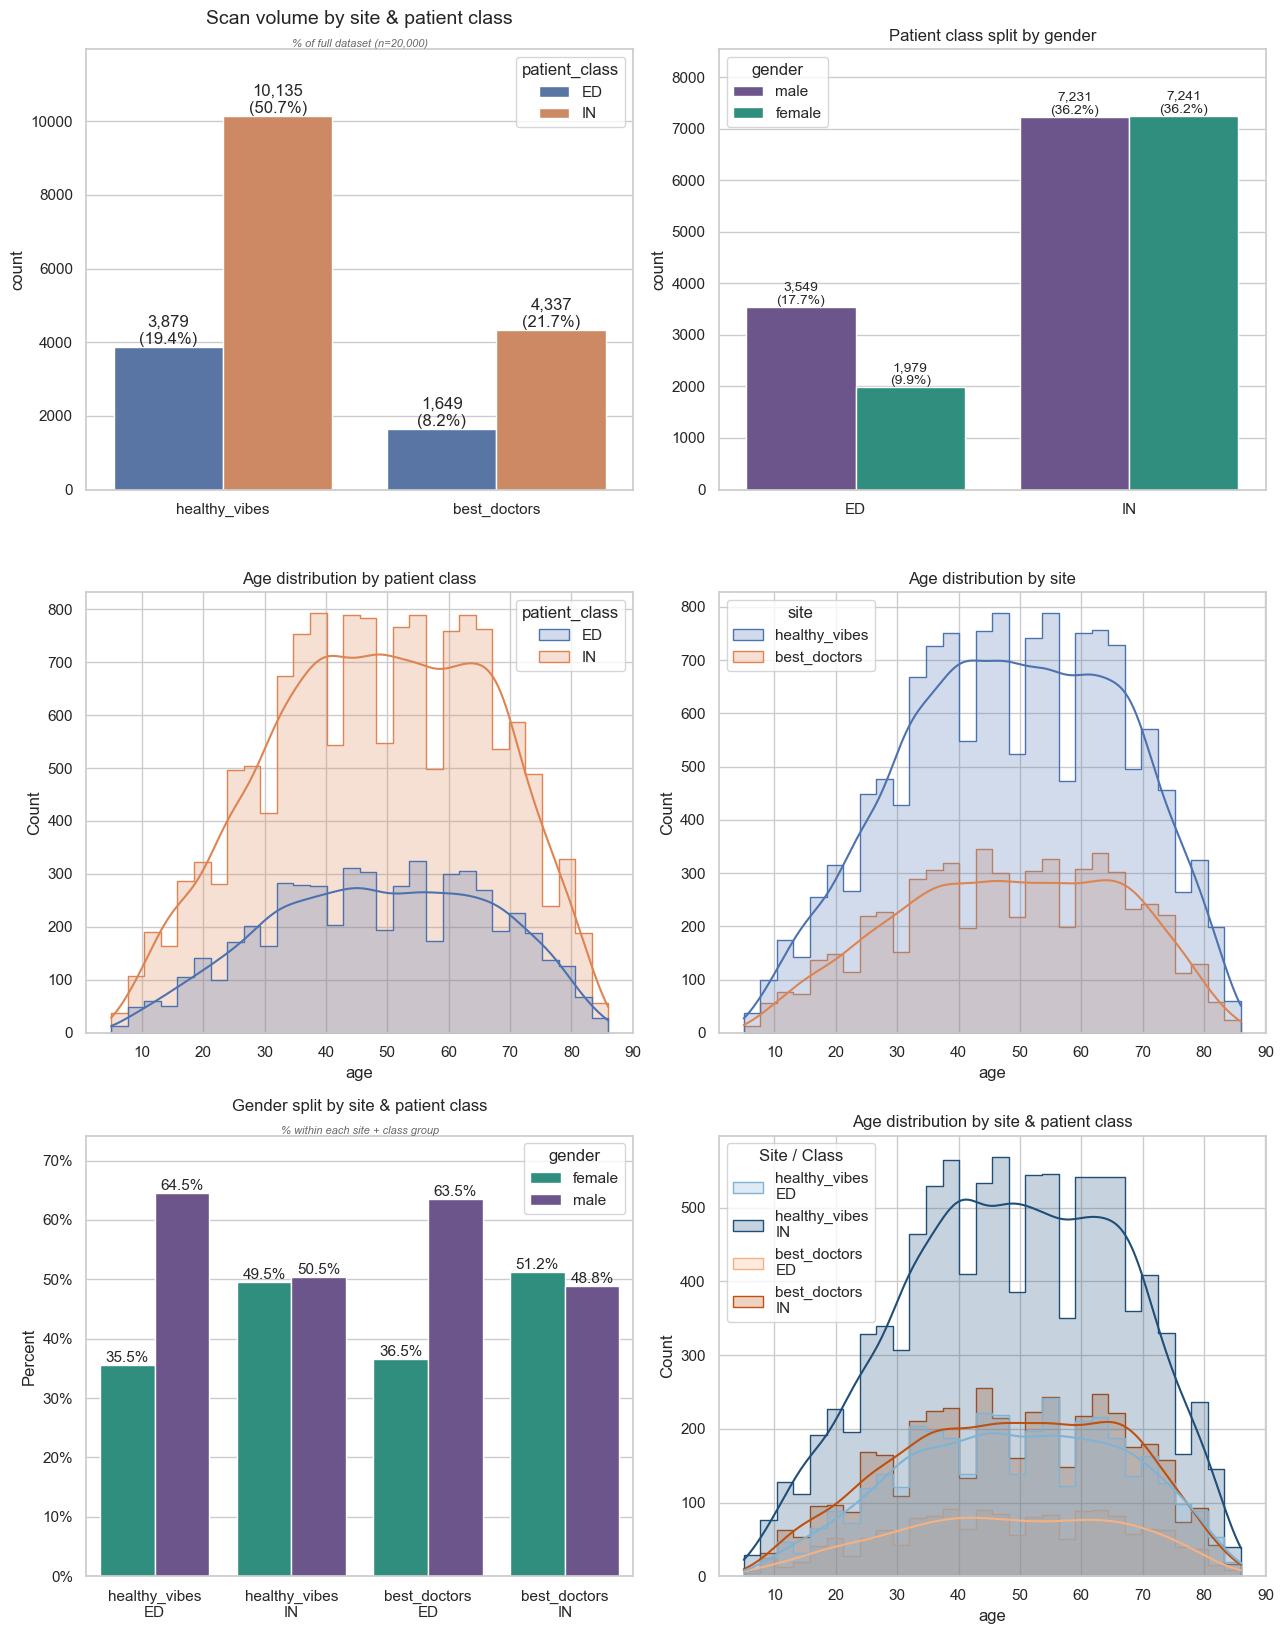

In [6]:
fig = viz.fig_population_overview(df)
plt.show()

- **Sites:** `healthy_vibes` accounts for ~70% of scans (14,014) vs. ~30% for `best_doctors`
  (5,986) - the two sites are not evenly sized.
- **Patient class:** inpatients (`IN`) dominate at both sites (~72% overall vs. ~28% `ED`),
  consistent across sites.
- **Gender:** 65% of the ED patients are male, a much higher percentage than the overall percentage in the sites (54%). This gender skew is a patient-class effect, not a site effect.
- **Age:** essentially uniform across every breakdown, mean and median age are 49-49 in every combination, so age isn't a meaningful differentiator between sites or patient classes here.
  
Both sites and classes are meaningfully imbalanced, which matters for how much we will trust each subgroup, and is relevant later on when we will choose the evaluation metrics. 

## 1.3 ICH prevalence

We would like to understand the ICH prevalence based on radiologists' answers, overall and also segmented by patient class and site type. The ICH prevalence is based in data_loader.py and exploration.py, and was calculated by averaging the number of positive values.

By site:
               ich_prevalence      n
site                                
best_doctors            0.100   5986
healthy_vibes           0.093  14014

By patient class:
               ich_prevalence      n
patient_class                       
ED                      0.047   5528
IN                      0.114  14472


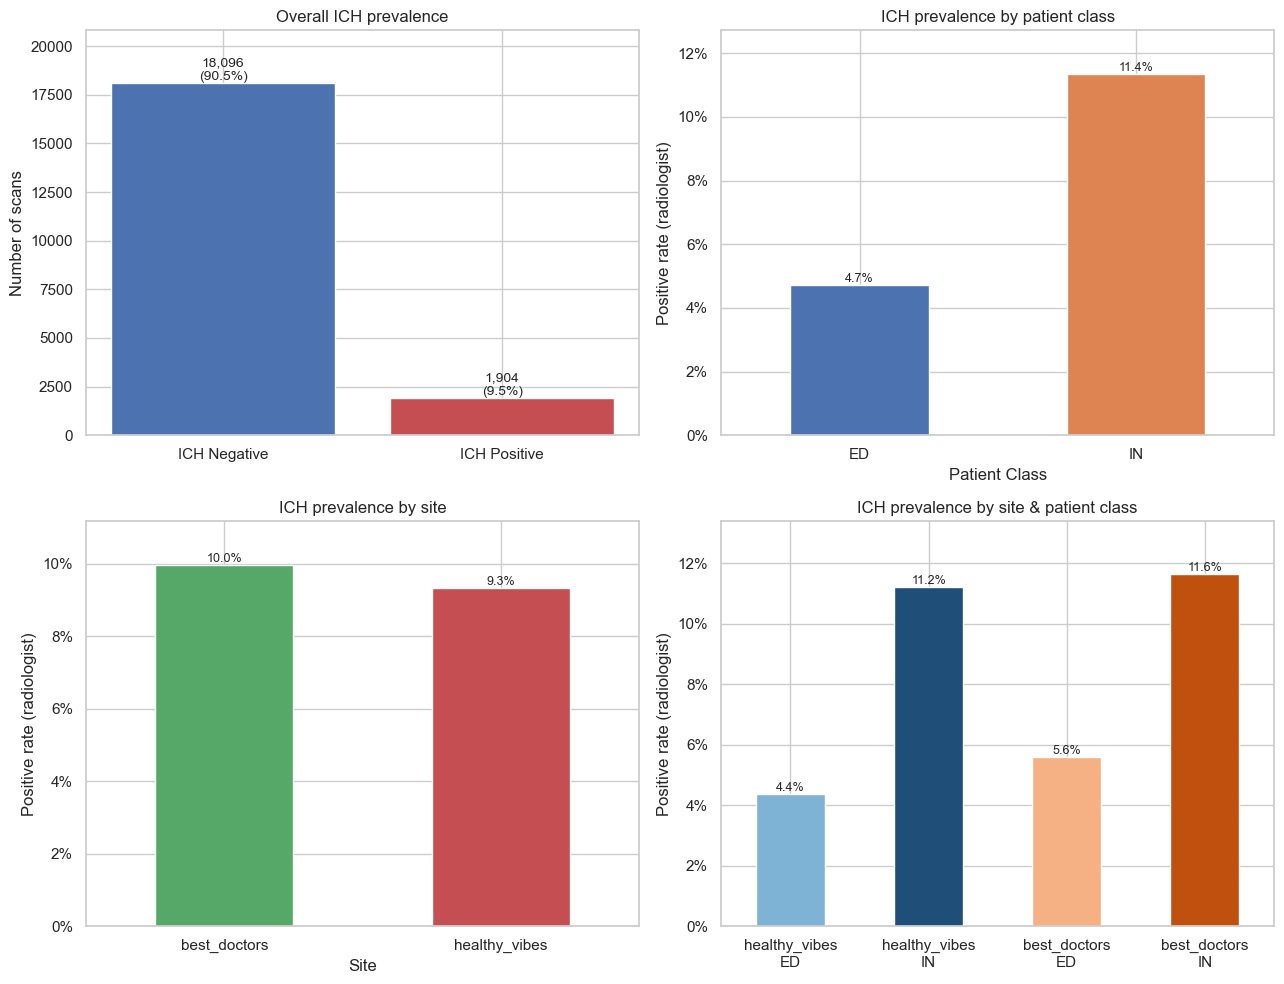

In [7]:
print("By site:")
print(ex.prevalence_by(df, ['site']).round(3))
print()
print("By patient class:")
print(ex.prevalence_by(df, ['patient_class']).round(3))

fig = viz.fig_prevalence(df)
plt.show()


**Takeaway:** overall ICH prevalence per the radiologist ground truth is **9.5%**. Prevalence
is similar across sites (9.3%-10.0%) but differs sharply by patient class: **11.4% for inpatients
vs. only 4.7% for ED patients**, more than double. This likely reflects differences in why a head CT gets ordered in each setting, rather than a data artifact. ED scans are usually ordered broadly - to rule out a bleed in patients with only mild or nonspecific symptoms, which casts a wide net and naturally yields a lower hit rate. Inpatient scans, by contrast, are typically ordered only when something specific changes during an admission, such as a new focal neurological deficit or a sudden drop in consciousness, which is a narrower and higher pre-test-probability trigger. 

In addition, this is an important base rate to keep in mind
when reading the algorithm performance numbers later on: a naive "always predict negative"
classifier would already score ~90% accuracy overall, and ~95% accuracy on ED alone.


## 1.4 Treatment duration

Now let's examine the treatment duration, meaning the time between the scan acquisition and the radiologist's sign time, in minutes. This is a core operational metric, which can help us understand how the sites and department function, regardless of any AI involvement.

       duration_min
count       20000.0
mean           10.3
std             2.4
min            -0.3
25%             8.7
50%            10.2
75%            11.8
max            20.3

                             pct_of_total    count       mean       std       min        50%        max
site          patient_class                                                                            
best_doctors  ED                      8.2   1649.0   8.042458  1.010464  4.240683   8.049933  11.215883
              IN                     21.7   4337.0  12.071871  2.535528  4.278450  12.056067  20.273883
healthy_vibes ED                     19.4   3879.0  10.011220  1.002989  6.947483  10.012333  13.383817
              IN                     50.7  10135.0  10.055531  2.500749 -0.270533  10.050683  19.483917


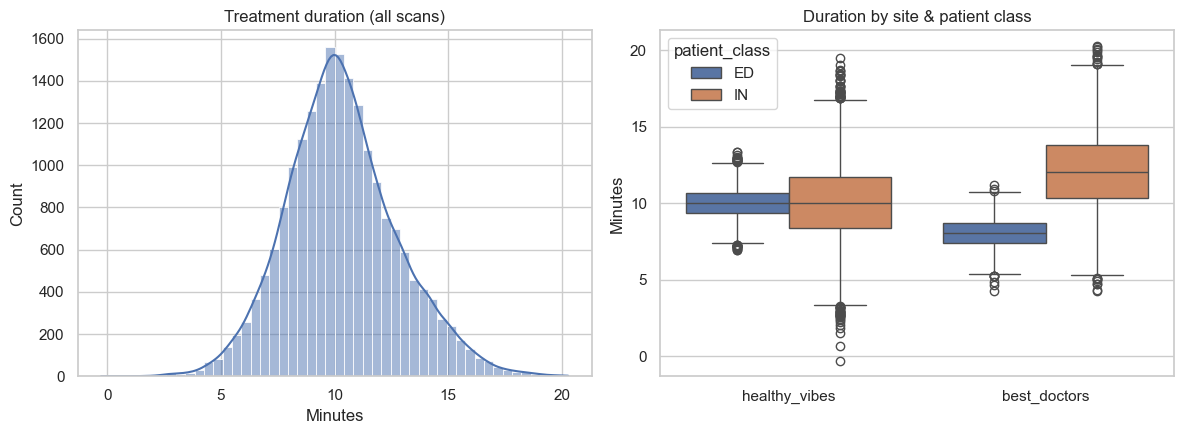

In [8]:
print(ex.duration_summary(df).round(1))
print()
print(ex.duration_summary(df, ['site', 'patient_class']))

fig = viz.fig_duration_distribution(df)
plt.show()


**Takeaway:** 
- Duration is tightly distributed around **~10 minutes** with max OF ~20 min. The bell-shaped, fairly symmetric curve is a strong signal in itself for the simulated process and generated data. In a real hospital workflow, sign-off durations are usually right-skewed - most reads happen quickly, but a long tail of cases get delayed (radiologist on a break, complex case, system lag, shift change, etc.).
- The one place a real difference shows up is **`best_doctors`**, where ED cases are
read notably faster than IN (**8.05 vs. 12.05 minutes median**) - consistent with acute
prioritization actually happening at that site. This is clinically sensible: ED cases should get prioritized reads over routine inpatient scans. Seeing that gap only at one site, and not the other, is the real finding here: **`healthy_vibes`** shows almost no difference
between ED and IN (**10.01 vs. 10.05 minutes**), 0.04 minutes, which is a 3-second difference - no visible prioritization effect. 
This could be originated from no acuity-based triage in the reading queue, or simply how this dataset was generated.

## 1.5 Caseload patterns

Before relying on scan timestamps elsewhere in this analysis, it's worth checking how volume varies by hour, day of week, and month. This can flag data-quality issues (like a day with zero scans), surface operational risk relevant to deployment (does the algorithm hold up under peak load, not just on average?), identify whether hour-of-day is a confound to control for in the later triage analysis, and sanity-check whether the timestamps follow a realistic clinical rhythm.

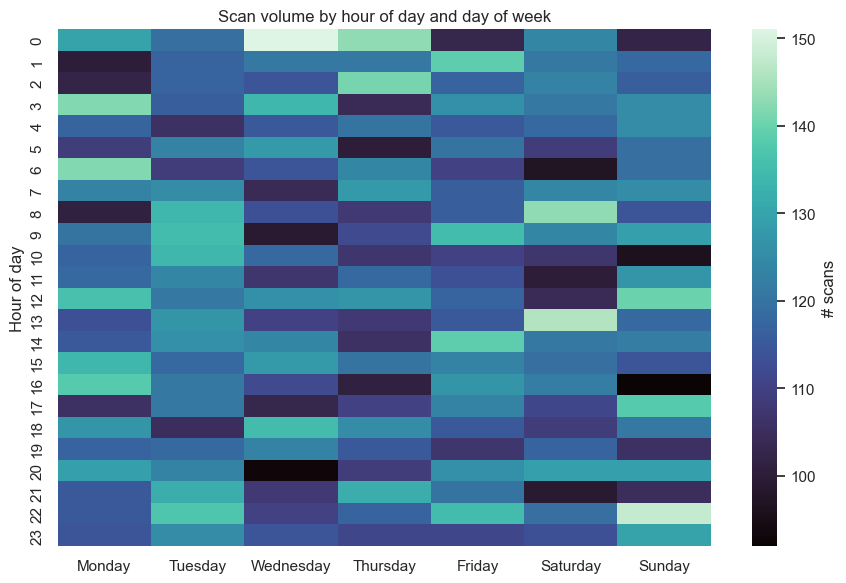

scan_month
2021-01    1795
2021-02    1605
2021-03    1847
2021-04    1824
2021-05    1901
2021-06    1777
2021-07    1853
2021-08    1848
2021-09    1832
2021-10    1899
2021-11    1819
Name: n_scans, dtype: int64


In [9]:
pivot = ex.volume_by_hour_dow(df)
fig = viz.fig_volume_heatmap(pivot)
plt.show()

print(ex.monthly_volume(df))

**Takeaway:** scan volume is stable month-over-month with no strong seasonality. However, the hour-of-day/day-of-week heatmap shows no clear time-of-day or weekly pattern. Volume looks roughly uniform across all hours and days, rather than following a typical daytime-heavy clinical rhythm, probably because of the randomness with which this dataset was generated. If this was a real dataset and, for some reason, it had this heatmap, it would be worth flagging to the Ops team that there is no pattern of high/low streams, so their resources should be spread evenly rather than concentrated around peak hours.

## 1.6 Age vs. ICH prevalence

The clinical background material calls out age as a risk
factor for ICH: elderly patients (and those with brain atrophy) are noted as
having increased susceptibility, largely via more fragile bridging veins and higher fall/trauma
risk. Gender isn't called out as a specific risk factor in that material, but it costs nothing to
check alongside age using the same functions.

In [10]:
print("By age group:")
print(ex.prevalence_by(df, ['age_group']).round(3))

By age group:
           ich_prevalence     n
age_group                      
0-18                0.114   945
18-30               0.115  2337
30-40               0.119  3299
40-50               0.112  3643
50-60               0.094  3560
60-70               0.070  3555
70-80               0.054  2183
80+                 0.054   478


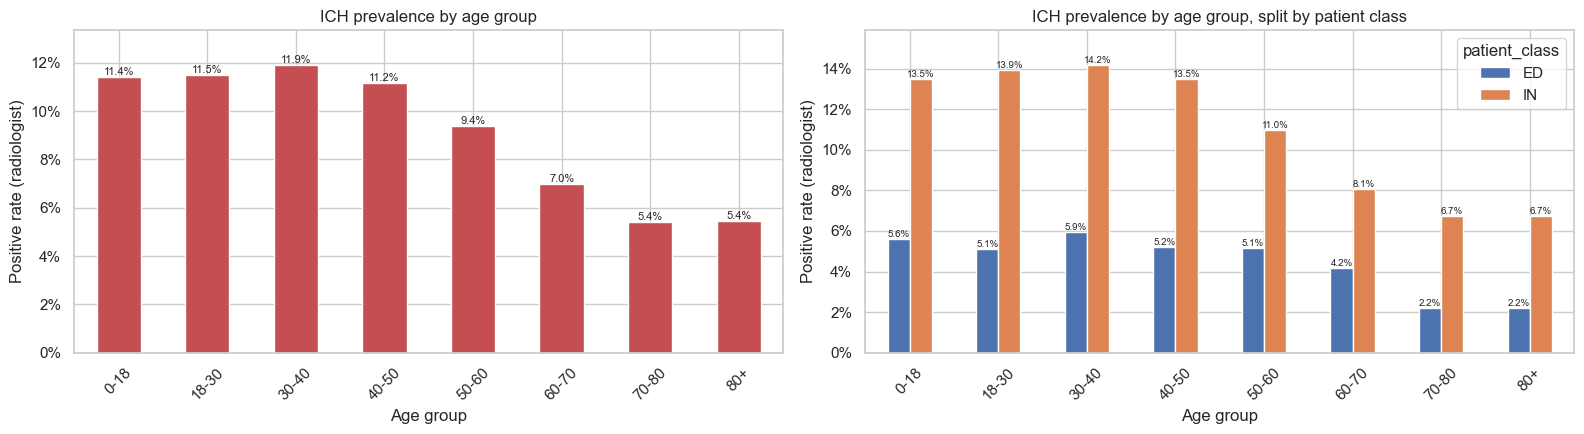

In [11]:
fig = viz.fig_age_prevalence(df, age_order=AGE_LABELS)
plt.show()

**Takeaway** - this result runs counter to the clinical background material.
ICH prevalence in this dataset **does not** rise with age as the reference material would suggest -
it's essentially flat on ~11%–12% from age 0 to 50, then declines steadily through the older age
brackets, bottoming out around 5.4% for 70–80 and 80+. This holds within ED and inpatient
populations separately, so it isn't just a byproduct of who ends up in which
department.

# Part 2: Algorithm Performance Evaluation

## 2.1 Confusion matrices & core metrics

First, we will examine the raw counts of each cell in the confusion matrix, in order to understand the proportions in each algorithm performences.

In [12]:
metrics = perf.algo_performance_table(df)
metrics

,TP,FN,FP,TN,n,sensitivity,specificity,PPV,NPV,accuracy,F1
algo1,965.0,939.0,312.0,17784.0,20000.0,0.507,0.983,0.756,0.950,0.937,0.607
algo2,1743.0,161.0,10347.0,7749.0,20000.0,0.915,0.428,0.144,0.980,0.475,0.249
algo3,1403.0,501.0,537.0,17559.0,20000.0,0.737,0.970,0.723,0.972,0.948,0.730


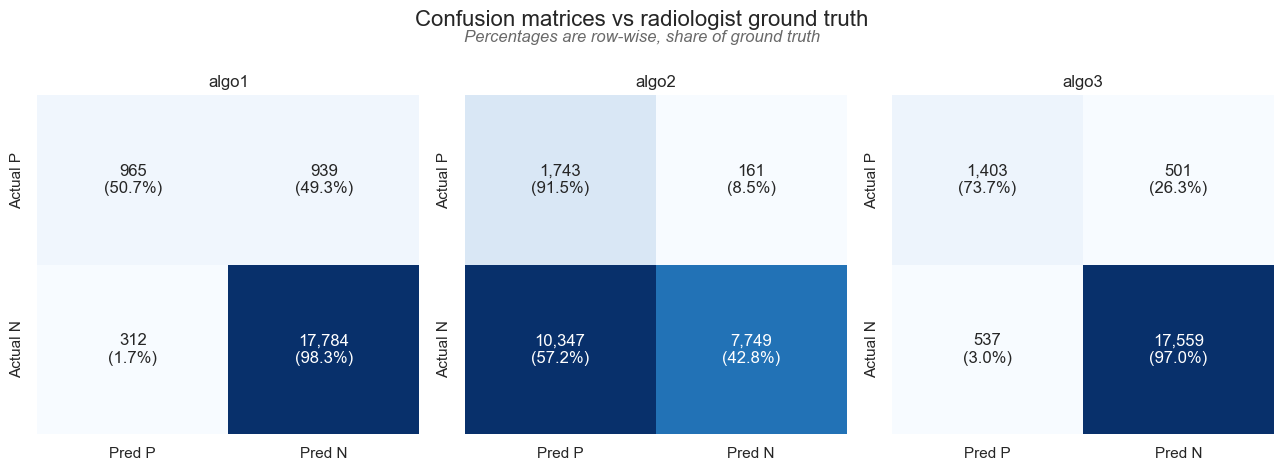

In [13]:
fig = viz.fig_confusion_matrices(df, perf.confusion_counts, perf.format_confusion_counts)
plt.show()

**Algo1**'s cell counts are the most evenly split in the top row (965 vs. 939), meaning it misses roughly as many actual-positive cases as it catches, unlike the other two algorithms.

**Algo2**, at first glance, has the highest share of TP and the lowest share of FN, but it's matrix stands out in the bottom row: 10,347 false positives is a strikingly large number, larger than its own TP count (1,743) - and the bottom-row split (10,347 vs. 7,749) is the only one of the three that isn't heavily lopsided toward the correct cell, visually signaling a large error volume at a glance. 

**Algo3**'s matrix looks the "cleanest" overall: both off-diagonal cells (501 and 537) are small relative to their row totals, and the bottom-right cell (17,559) dominates its row almost completely. The matrix pattern most closely resembles a well-behaved classifier where errors are the visible minority in both rows.

These raw counts hint at very different tradeoffs across the three algorithms - the metrics below make those tradeoffs directly comparable:

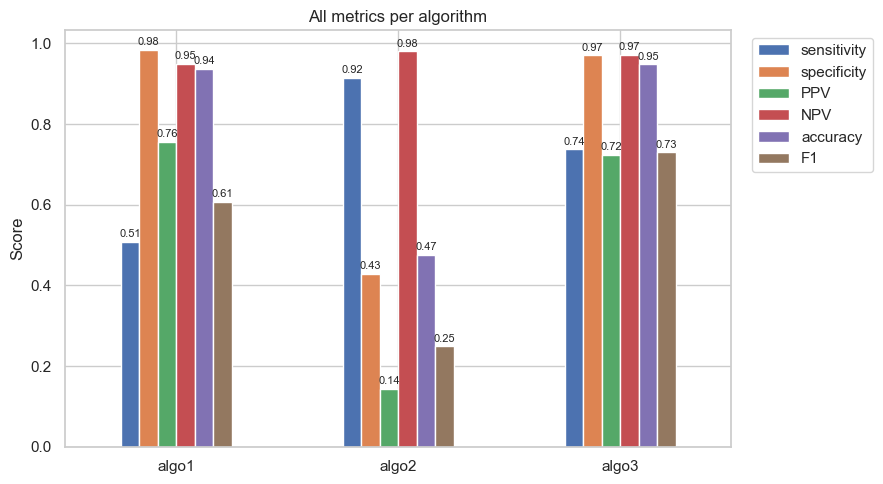

In [14]:
fig = viz.fig_metrics_bar(metrics)
plt.show()

**Metric definitions:**

- **Sensitivity** (recall) - `TP / (TP + FN)`
  Of all actual positive cases, shows the fraction the algorithm correctly catches and doesn't misclassify real cases.

- **Specificity** - `TN / (TN + FP)`
  Of all actual negative cases, shows the fraction the algorithm correctly catches.

- **PPV** (precision) - `TP / (TP + FP)`
  Of all cases the algorithm flagged as positive, shows the fraction that were actually positive, meaning how much should we trust a positive prediction.

- **NPV** - `TN / (TN + FN)`
  Of all cases the algorithm flagged as negative, it shows the fraction that were actually negative, meaning how much should we trust a negative prediction. 

- **Accuracy** - `(TP + TN) / (TP + TN + FP + FN)`
  Of all cases overall, it shows the fraction the algorithm gets right. 

- **F1** - `2 × (Precision × Recall) / (Precision + Recall)`
  The harmonic mean of precision and recall, balancing between the two metrics. Useful as a single summary number when both false negatives and false positives matter, especially under class imbalance where accuracy alone is unreliable.

For a more convenient understanding of the comparison within each metric, we can also examine the transposed barplot:

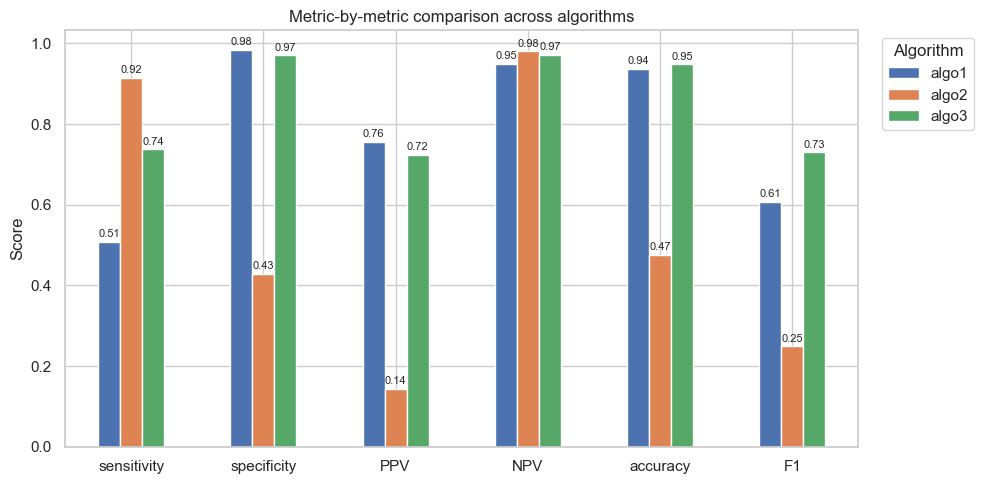

In [15]:
fig = viz.fig_metrics_bar_by_metric(metrics)
plt.show()

**The three algorithms have very different operating points:**

- **algo1** is conservative: highest PPV (76%) and specificity (98%), but misses about
  half the true positives (sensitivity **51%**). Whatever it flags is very likely to be real, but
  it can't be trusted as a safety net on its own.
- **algo2** is the opposite extreme - very sensitive (92%), catches almost all true positives
  but at the cost of PPV, which is just **14%**, and specificity collapses to 42.8%. In practice, ~86%
  of its positive alerts would be false alarms - this would almost certainly cause alert fatigue if
  used to drive triage or interruptive workflow.
- **algo3** has the best balance: sensitivity 73.7%, specificity 97%, PPV 72%, and therfore has the highest
  **F1 (0.73)**.

**Takeaway**:
- Accuracy is the most misleading with imbalanced classes, and in this case we do have imbalanced classes (base rate for positive ICH is 9.5%). Therefore, we didn't give it much weight in the overall decision.
- The two metrics that aren't directly biased by ICH prevalence are sensitivity and specificity, since both are calculated in only one row of the confusion metrics, and this way they don't take into account the prevalence. In the overall analysis, **algo3 looks like the best candidate** to implement not only because it has the best F1 score but because in terms of sensitivity and specificity it has the best balance.
- We can observe that algo1 and algo3 differ from one another mainly in the sensitivity (which directly affects the F1 score), **while in all of the other metrics they are very similar.**

## 2.2 Performance by Site & Class

So far, we examined the overall performances of each algorithm, but before recommending an algorithm for deployment, it's worth confirming that its ranking holds within each site, each patient class, and their combinations - not just in aggregate. We'd generally expect the ranking to hold, since sensitivity and specificity are largely intrinsic to how each algorithm is calibrated (its decision threshold, what features it weighs) - but that's an assumption worth verifying before it's used to justify a real deployment decision. Most metrics should track together consistently across subgroups unless something about a specific subgroup meaningfully changes the underlying trade-off.

In [16]:
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)
print("By site:")
display_site = perf.algo_performance_by_group(df, 'site')
print(display_site)
print()
print("By patient class:")
display_class = perf.algo_performance_by_group(df, 'patient_class')
print(display_class)


By site:
            site   algo      n  sensitivity  specificity    PPV    NPV  accuracy     F1
0   best_doctors  algo1   5986        0.538        0.982  0.766  0.950     0.938  0.632
1   best_doctors  algo2   5986        0.906        0.428  0.149  0.976     0.476  0.257
2   best_doctors  algo3   5986        0.742        0.969  0.729  0.971     0.947  0.735
3  healthy_vibes  algo1  14014        0.493        0.983  0.751  0.950     0.937  0.595
4  healthy_vibes  algo2  14014        0.920        0.428  0.142  0.981     0.474  0.246
5  healthy_vibes  algo3  14014        0.735        0.971  0.721  0.973     0.949  0.728

By patient class:
  patient_class   algo      n  sensitivity  specificity    PPV    NPV  accuracy     F1
0            ED  algo1   5528        0.552        0.985  0.646  0.978     0.965  0.595
1            ED  algo2   5528        0.916        0.431  0.074  0.990     0.454  0.137
2            ED  algo3   5528        0.770        0.969  0.554  0.988     0.960  0.644
3       

We calculated it to examine the ranking of the algorithms within each metric under each subset: for example, the overall ranking we saw before for F1 was algo3 > algo1 > algo2, and we can observe that this ranking holds for each site and for each patient class. The same goes for every ranking of every metric, except for the accuracy of ED: instead of having algo3 > algo1 > algo2, it has algo1 (0.965) > algo3 (0.960) > algo2 (0.454).

To understand this ranking holds not only on each subset on its own but rather on site+patient class combined, we will check the following:

In [17]:
print("By site + patient class:")
display_combo = perf.algo_performance_by_group(df, ["site", "patient_class"])
print(display_combo)

By site + patient class:
             site patient_class   algo      n  sensitivity  specificity    PPV    NPV  accuracy     F1
0    best_doctors            ED  algo1   1649        0.576        0.983  0.662  0.975     0.960  0.616
1    best_doctors            ED  algo2   1649        0.924        0.423  0.086  0.989     0.451  0.158
2    best_doctors            ED  algo3   1649        0.761        0.970  0.603  0.986     0.959  0.673
3    best_doctors            IN  algo1   4337        0.531        0.981  0.791  0.941     0.929  0.635
4    best_doctors            IN  algo2   4337        0.903        0.431  0.173  0.971     0.486  0.290
5    best_doctors            IN  algo3   4337        0.739        0.969  0.758  0.966     0.942  0.748
6   healthy_vibes            ED  algo1   3879        0.538        0.986  0.636  0.979     0.966  0.583
7   healthy_vibes            ED  algo2   3879        0.911        0.434  0.068  0.991     0.454  0.127
8   healthy_vibes            ED  algo3   3879   

When examining each one of these 12 combinations, we can see that the same ranking for each metric holds for all of the combinations, except for the two combinations of best_doctors/ED and healthy_vibes/ED for accuracy alone. In these combinations, we are getting the same changed ranking as we saw in the patient class only.

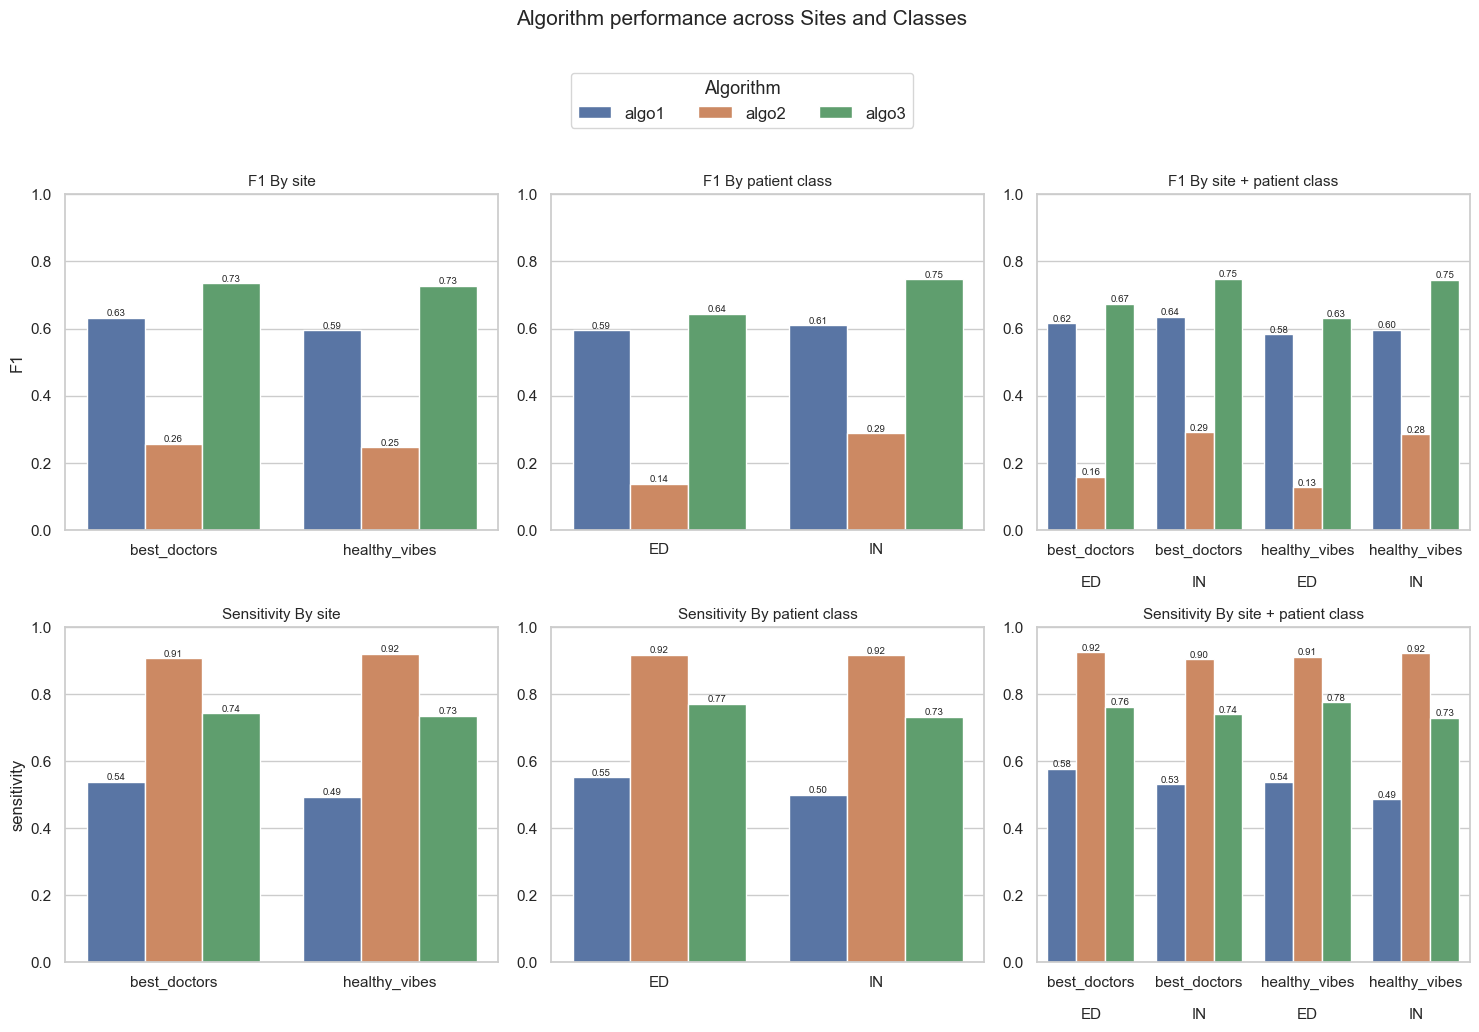

In [18]:
by_site = perf.algo_performance_by_group(df, "site")
by_class = perf.algo_performance_by_group(df, "patient_class")
by_combo = perf.algo_performance_by_group(df, ["site", "patient_class"])

fig = viz.fig_performance_by_breakdown(by_site, by_class, by_combo)
plt.show()

**Takeaway:** 
- **Ranking holds everywhere except accuracy**. Each algorithm's ranking on every metric (e.g., algo3 > algo1 > algo2 on F1) holds across both sites, both patient classes, and all 24 combinations - except accuracy (which is reasonable because of the imbalanced classes). This makes sense: sensitivity and specificity are intrinsic to how each algorithm is calibrated, not to the population it's scored on, so if algo3 wins on F1 here, we'd expect that advantage to persist at a new site or with a different ED/IN mix.
- **That the flip was isolated to accuracy (not F1/PPV) is actually reassuring**. If F1 or PPV had flipped too, that would suggest real behavioral differences in ED, not just a scoring artifact. Since only accuracy moved, it confirms the algorithms behave consistently - the ED effect is a measurement quirk of accuracy, not a real performance change.
- **PPV drops sharply in ED for every algorithm** (e.g., algo3: 55.4% ED vs. 76.2% IN) - a direct consequence of ED's lower ICH prevalence (4.7% vs. 11.4%), not weaker algorithm performance. Per Bayes' theorem, PPV is inherently base-rate sensitive: with fewer true positives to draw from, the same false-positive rate yields a worse false-positive ratio. Practically, this means any PPV target must be scoped to the population it's measured on - a global 9–10%-prevalence PPV number would overstate how trustworthy ED alerts actually are.

## 2.3 Algorithm Runtime comparison

So far, we compared the performences of the algorithms by their predictions. Another crussial aspect of their performences is their runtime:

                   mean     std     min     50%      max
algo1_runtime_s   44.99   15.02  -13.87   44.95   103.45
algo2_runtime_s  149.92   29.96   28.44  150.08   275.59
algo3_runtime_s  601.37  120.52  146.39  601.66  1083.83


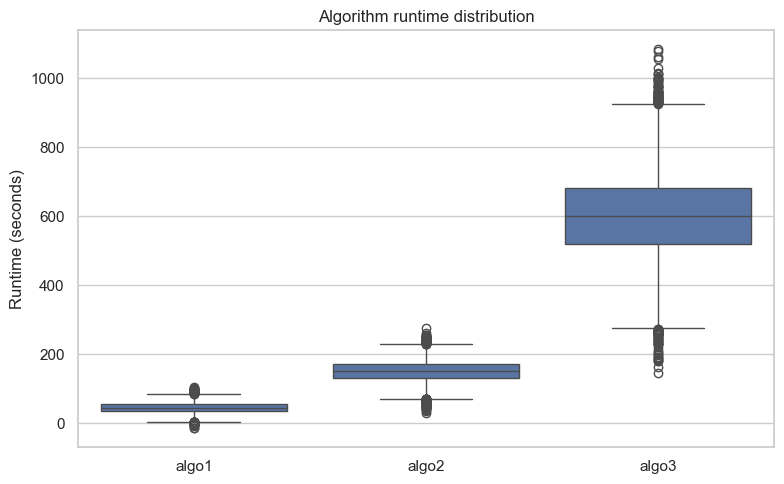

In [19]:
runtime = perf.runtime_summary(df)
print(runtime)

fig = viz.fig_runtime_boxplot(df)
plt.show()

**Takeaway:** runtime varies enormously - **algo1 median is 45s, algo2 is 150s, algo3 is 601s (10 minutes)**
on average. This matters a great deal operationally: algo3 has the best F1 score, but it is **roughly 13x slower than algo1** on average. algo3's main advantage over algo1 was its F1 score (0.7 vs. 0.6), but with the trade-off of being 13x slower, that extra 0.1 F1 score isn't worth it.

Not only the average and the median counts: algo1 and algo2 both have narrow boxes and whiskers - low risk of an unexpectedly slow read. algo3, by contrast, has a substatually wider box, wider whiskers, and a longer tail of outliers stretching past 1000 seconds (more then 18 minutes). In a clinical triage context, this matters more than the median alone: an algorithm that's usually 10 minutes but occasionally 18 minutes is harder to build a reliable workflow around than one that's consistently fast, even if the consistent one is slower on average.

Its ~10-minute
average runtime means its output usually won't even be ready before the radiologist has already
finished a typical read (recall from 1.3, median read time is ~10 minutes too) - so today, algo3's
prediction likely can't inform triage or the read itself in real time, only retrospective QA. algo1
is fast enough to gate the acute queue in real time; algo2 is fast but too noisy to trust for that
purpose given its 14% PPV.

#### Algorithm runtime before radiologist

Given each algorithm's actual runtime,
would its result even have been ready in time to matter for that scan's read? This uses only
timestamps that are genuinely independent facts about the pipeline: `scan_timestamp` ->
`algos_start_run` -> `algoX_finish_run`, compared against `radiologist_sign_time`.

The significant part is the time between `algoX_finish_run` and `radiologist_sign_time`. So we will check for each algorithm the share of scans it managed to finish the run before the radiologist. In addition, it's not enough to finish before the radiologist, but also it matters how much time before the radiologist, so we will calculate this metric also (as a median, since runtime has a long right tail).

Since only ~10% of the data are truly positive scans and they are the most important, we will check separately on them. Specifically, we will also check on the truly positive in the ED, since they are at the highest risk.

In [20]:
summary_all = perf.actionability_summary(df)
print("All scans:")
print(summary_all)

pos = df[df['rad_positive']]
summary_pos = perf.actionability_summary(pos)
print()
print("Truly positive scans only:")
print(summary_pos)

ed_pos = df[(df['rad_positive']) & (df['is_ed'])]
summary_ed_pos = perf.actionability_summary(ed_pos)
print()
print(f"ED + truly positive scans only:")
print(summary_ed_pos)

All scans:
    algo      n  pct_in_time  median_lead_min_when_in_time
0  algo1  20000        1.000                         8.893
1  algo2  20000        0.999                         7.161
2  algo3  20000        0.460                         1.964

Truly positive scans only:
    algo     n  pct_in_time  median_lead_min_when_in_time
0  algo1  1904        1.000                         9.038
1  algo2  1904        0.998                         7.296
2  algo3  1904        0.488                         2.042

ED + truly positive scans only:
    algo    n  pct_in_time  median_lead_min_when_in_time
0  algo1  261        1.000                         8.006
1  algo2  261        1.000                         6.291
2  algo3  261        0.284                         1.010


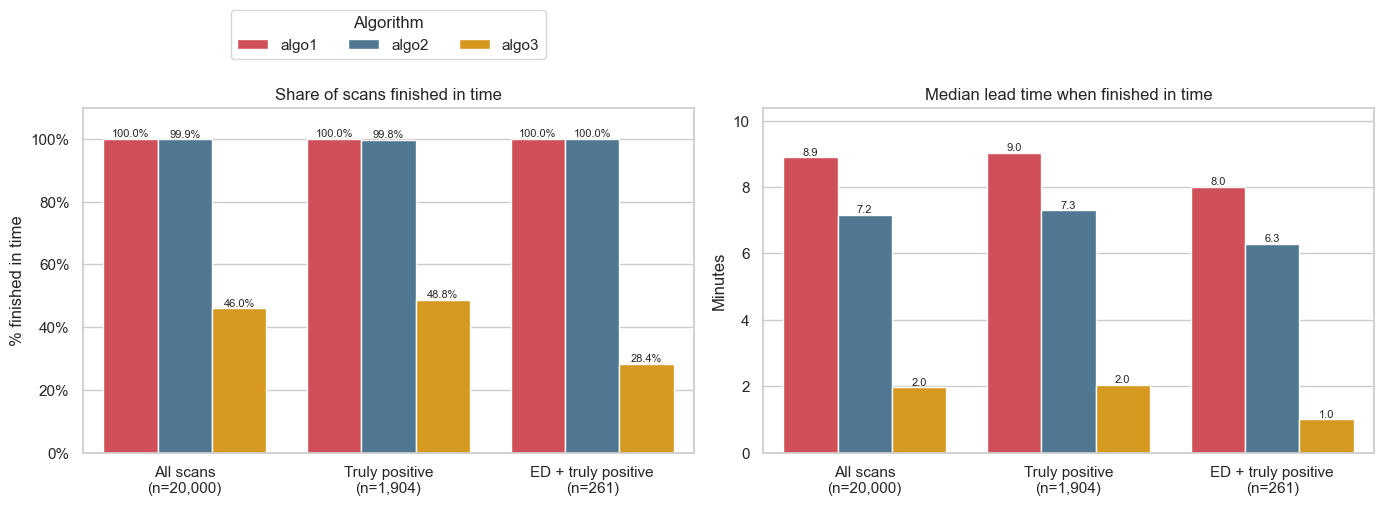

In [21]:
fig = viz.fig_actionability_by_subset({
    "All scans": summary_all,
    "Truly positive": summary_pos,
    "ED + truly positive": summary_ed_pos,
})
plt.show()

**Takeaway**:
- algo1 and algo2 are essentially always ready before the radiologist's independent read finishes, with ~7-9 minutes of lead time on average when they are.
- algo3, despite having the best performances in metrics, **is only ready in time 46.0%** of the time overall, and just 28.4% of the
time on ED true positives specifically, the exact population where fast triage matters most.
- The practical consequence is that **algo3 cannot be trusted as a real-time triage or
decision-support signal**. Over half the time, by the time it would have something to say, the
read is already done. Its accuracy is real and valuable, but only for retrospective QA, auditing,
or second-read workflows.

We should also understand the time of `scan_timestamp` -> `algos_start_run`, which is the server latency between each scan timestamp and the algorithms start running (the same time for all three algorithms):

In [22]:
print("The seconds between the scan_timestamp and the algos_start_run:")
print(df['start_delay_s'].describe().round(2))
print()

by_site = df.groupby('site')['start_delay_s'].describe()[['mean','50%','std']].round(2)
by_class = df.groupby('patient_class')['start_delay_s'].describe()[['mean','50%','std']].round(2)
by_combo = df.groupby(['site','patient_class'])['start_delay_s'].describe()[['mean','50%','std']].round(2)

perf.side_by_side([by_site, by_class, by_combo], ["By site:", "By patient class:", "By site + patient class:"], gap=8)

The seconds between the scan_timestamp and the algos_start_run:
count    20000.00
mean        35.43
std         17.87
min         -0.79
25%         22.50
50%         28.81
75%         50.29
max         97.45
Name: start_delay_s, dtype: float64

By site:                                 By patient class:                         By site + patient class:                        
                mean    50%   std                        mean    50%    std                                      mean    50%    std
site                                     patient_class                             site          patient_class                     
best_doctors   59.90  59.68  9.92        ED             35.37  28.89  17.85        best_doctors  ED             59.82  59.29  10.13
healthy_vibes  24.98  25.03  6.98        IN             35.45  28.78  17.87                      IN             59.92  59.78   9.84
                                                                                   healthy_vibe

**Server latency** averages ~35 seconds
overall, but varies a lot by site: `healthy_vibes` ~25s vs. `best_doctors` ~60s, more than double.
On its own this is a minor infrastructure note for Ops, not a driver of algorithm quality, but
it eats into the time budget below, so it's worth having in view before looking at runtime.

## 2.4 Pairwise Agreement Between Algorithms

Now, let's compare the actual prediction between each pair of the 3 algorithms for each one of the rows in the dataset:

       algo1  algo2  algo3
algo1  1.000  0.456  0.928
algo2  0.456  1.000  0.455
algo3  0.928  0.455  1.000


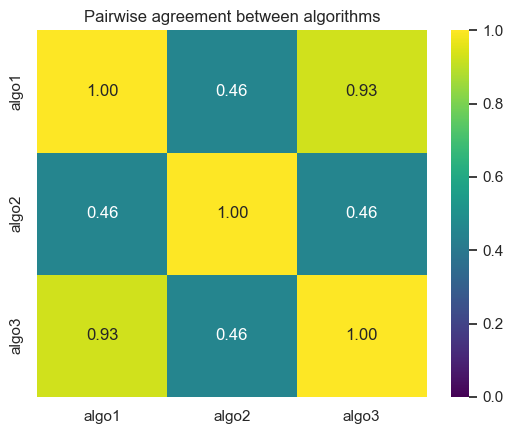

In [23]:
agreement = perf.pairwise_agreement(df)
print(agreement)

fig = viz.fig_agreement_heatmap(agreement)
plt.show()

The main finding is that algo1 and algo3 are nearly the same algorithm in practice: they give the same answer on 93% of all 20,000 scans. Combined with what we saw before that both are relatively conservative, both have high specificity/PPV, both rank similarly on every metric we checked, this strongly suggests algo1 and algo3 aren't just performing similarly - they're making nearly identical decisions on individual cases, not just landing on similar aggregate scores by coincidence.

Algo2 is completely different from the other two algorithms, having ~50% agreement with each one of them, essentially close to a coin flip. This is consistent withthe algo2's aggressive "flag almost everything" behavior isn't a variation on the same decision boundary as algo1/algo3, it's operating at a fundamentally different operating point.

#### Digging into the disagreement zone

algo1 and algo3 disagree on 7.2% of scans. Since these are both binary P/N calls, exactly one of
the two is "right" (matches the radiologist) on every disagreement row by construction, so the
interesting question isn't "who's right more often" in the abstract, it's *what kind* of
disagreement each direction represents.

In [24]:
da = perf.disagreement_analysis(df, 'algo1', 'algo3')
for k, v in da.items():
    print(f"{k}: {v}")


n_disagree: 1439
pct_disagree: 0.072
algo1_only_positive_n: 388
algo1_only_positive_hit_rate: 0.204
algo3_only_positive_n: 1051
algo3_only_positive_hit_rate: 0.492


Of the 1,439 disagreement rows:
- 1,051 (73%) are "algo3 says P, algo1 says N", algo3 catching something algo1 misses. By comparing those to the radiologist answer, they were real positive on **49.2%** of the time, essentially a coin flip.
- Only 388 (27%) are the other direction, "algo1 says P, algo3 says N", and by comparing those to the radiologist answer, they were real positive **20.4%** of the time, meaning most of what algo1 adds beyond algo3 is noise.

#### Pairwaise agreement on actual positievs and negatives

Radiologist-positive scans only (n=1904):
       algo1  algo2  algo3
algo1  1.000  0.560  0.687
algo2  0.560  1.000  0.767
algo3  0.687  0.767  1.000


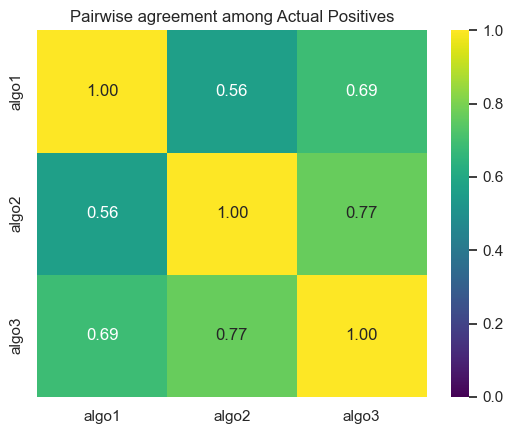

Radiologist-negative scans only (n=18096):
       algo1  algo2  algo3
algo1  1.000  0.445  0.953
algo2  0.445  1.000  0.422
algo3  0.953  0.422  1.000


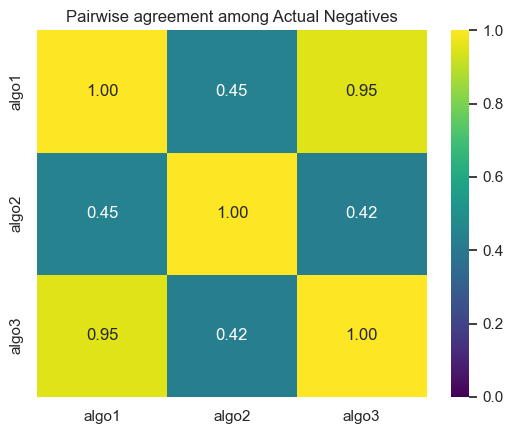

In [25]:
pos = df[df['rad_positive']]
neg = df[~df['rad_positive']]

agreement_pos = perf.pairwise_agreement(pos)
print(f"Radiologist-positive scans only (n={len(pos)}):")
print(agreement_pos)

fig = viz.fig_agreement_heatmap(agreement_pos, title="Pairwise agreement among Actual Positives")
plt.show()

agreement_neg = perf.pairwise_agreement(neg)
print(f"Radiologist-negative scans only (n={len(neg)}):")
print(agreement_neg)

fig = viz.fig_agreement_heatmap(agreement_neg, title="Pairwise agreement among Actual Negatives")
plt.show()

## 3. Recommendations

**For the Algo team:**

- Fix algo3's speed first: if possible, to get a 3-4x runtime reduction (~150–200s) without changing anything related to its classification process, then it would make it the perfect model.
- Lowering algo2 false positives: currently they are substantially elevated, without damaging the true positives too much. For example, uplifting the threshold only a little bit could potentially improve the balance.
- Uplifting algo1 true positives, which right now are the smallest amount and are its major weakness.

**For the Product team:**

- Design a tiered notification system: The three algos carry different reliability, so we could make their alerts look different to a radiologist in UX/UI matters.
- Build an algo3 retrospective-review workflow: While algo3 stays too slow for real-time use, we can use it afterward in retrospect to automatically flag cases that the other models predicted wrong, route them to someone for regular review, define what happens if a real miss is confirmed, and feed confirmed cases back to the Algo team as training data.

**For the Ops team:**

- Improving algo3 resources: considering giving algo3 larger and dedicated resources, which maybe could solve its runtime issue.
- Investigate healthy_vibes' ED triage gap: unlike the other site, its ED reads show no duration advantage over IN, worth confirming whether this reflects a deliberate site practice or an infrastructure/workflow issue silently blocking prioritization.
- Investigate best_doctors' server latency: This site shows roughly double the delay between scan acquisition and algorithms start running compared to healthy_vibes (~60s vs ~30s). While the absolute impact is minor, closing this gap could be beneficial.


**Ideas for future analysis**:

- Reweight matrices and metrics for class imbalance: Imbalance had a major effect on the performance evaluation, worth testing whether reweighted matrices would change which algorithm actually looks best.
- Algorithm performance by age group: Considering ICH prevalence was higher in younger ages, we can extend the subgroup analysis to age bins to confirm whether the metrics stay stable across ages the way they did for site/class.
- Disagreements drilldowns: Extend the disagreement analysis to algo2's disagreements with each algo, inspecting the specific cases, not just the aggregate counts.